# Robust F0 Estimation in Conversational Speech
# 1. Methodology and Diagnostics

This notebook establishes the methodological foundation for all subsequent analyses.
Our goals are to:

1. Validate the need for robust (percentile-based) F0 statistics
2. Diagnose pitch instability caused by non-modal phonation (e.g., laughter, coughs)
3. Quantify voiced ratio behavior across the Seamless Interaction dataset
4. Justify design decisions used in downstream demographic and social analyses

This notebook does not test sociolinguistic hypotheses.
Instead, it ensures that our acoustic measurements are reliable, interpretable, and defensible.


## 1.0 Setup

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from pathlib import Path

sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14

In [2]:
ROOT = Path("/home/ahallur1/spear/Seamless_Experiments/F0")
CSV_PATH = ROOT / "seamless_f0_features.csv"

assert CSV_PATH.exists(), f"CSV not found: {CSV_PATH}"

df = pd.read_csv(CSV_PATH)

print(f"Loaded {len(df):,} conversation sides")
print(f"Total columns: {df.shape[1]}")
df.head()

Loaded 129,215 conversation sides
Total columns: 29


,wav_path,orig_id,vendor_id,session_id,subset,split,relationship,relationship_detail,total_duration_s,voiced_duration_s,...,f0_p90,f0_range_p10_p90,f0_mean_p10_p90,f0_std_p10_p90,f0_p25,f0_p75,f0_range_p25_p75,f0_mean_p25_p75,f0_std_p25_p75,status
0,/export/fs06/corpora8/seamless_interaction/dat...,V00_S0644_I00000129_P0799,V00,644.0,seamless_interaction,datasets,stranger,stranger,176.0,1.510257,...,257.702956,169.659103,129.342323,35.164693,102.240972,152.353270,50.112298,122.296057,13.193822,LOW_VOICED_RATIO
1,/export/fs06/corpora8/seamless_interaction/dat...,V00_S0925_I00000135_P0383,V00,925.0,seamless_interaction,datasets,stranger,stranger,150.0,22.954591,...,139.564031,50.783169,107.720842,12.364215,95.536289,119.336644,23.800355,106.483735,6.880563,OK
2,/export/fs06/corpora8/seamless_interaction/dat...,V00_S2050_I00001126_P1308A,V00,2050.0,seamless_interaction,datasets,stranger,stranger,260.0,65.770118,...,250.933452,106.699420,188.463498,28.398007,158.081343,216.795628,58.714285,186.753980,17.310174,OK
3,/export/fs06/corpora8/seamless_interaction/dat...,V00_S0054_I00000785_P0084,V00,54.0,seamless_interaction,datasets,stranger,stranger,316.0,34.494366,...,248.411987,138.311373,157.811124,33.834572,124.314080,192.417948,68.103868,153.570040,19.079899,OK
4,/export/fs06/corpora8/seamless_interaction/dat...,V00_S0086_I00000581_P0127,V00,86.0,seamless_interaction,datasets,stranger,stranger,220.0,84.611538,...,153.497332,56.747125,117.738506,14.272846,104.154091,132.143813,27.989722,115.843420,7.760624,OK


## 1.1 Raw vs Robust F0 Metrics



In conversational speech, pitch trackers often capture extreme F0 values during:
- laughter
- coughs
- creaky voice
- breathy phonation

These events inflate:
- maximum F0
- F0 range
- F0 standard deviation

We compare:
- Raw metrics
- 10–90 percentile trimmed metrics
- 25–75 percentile trimmed metrics

to demonstrate why robust statistics are necessary.

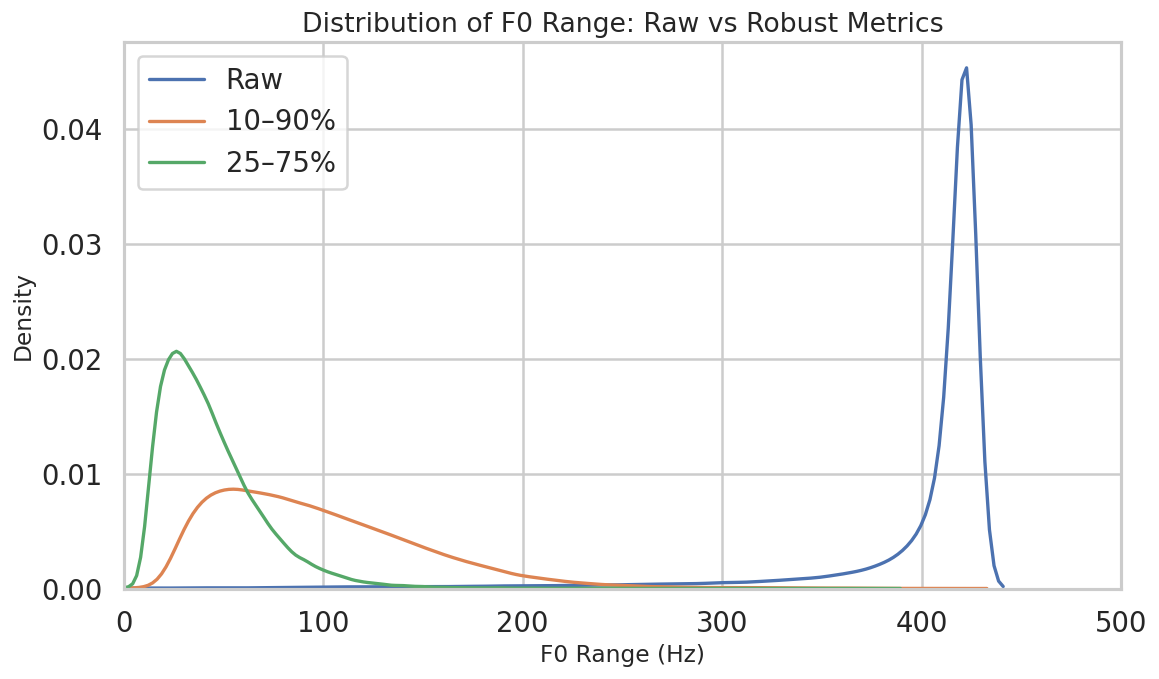

In [3]:
plt.figure(figsize=(10, 6))

sns.kdeplot(df["f0_range_raw"], label="Raw", linewidth=2)
sns.kdeplot(df["f0_range_p10_p90"], label="10–90%", linewidth=2)
sns.kdeplot(df["f0_range_p25_p75"], label="25–75%", linewidth=2)

plt.xlabel("F0 Range (Hz)")
plt.ylabel("Density")
plt.title("Distribution of F0 Range: Raw vs Robust Metrics")
plt.legend()
plt.xlim(0, 500)
plt.tight_layout()
plt.show()

**Key observations:**
- Raw F0 range exhibits a heavy right tail extending beyond physiologically plausible speech
- 10–90 percentile trimming preserves expressive variability
- 25–75 percentile trimming captures core modal pitch behavior

This confirms that raw F0 range is not suitable for conversational speech analysis.

## 1.2 Voiced Ratio Diagnostics


Voiced ratio represents the proportion of frames for which pitch is detected.

Rather than using voiced ratio as a strict exclusion criterion,
we treat it as a diagnostic signal indicating potential instability.

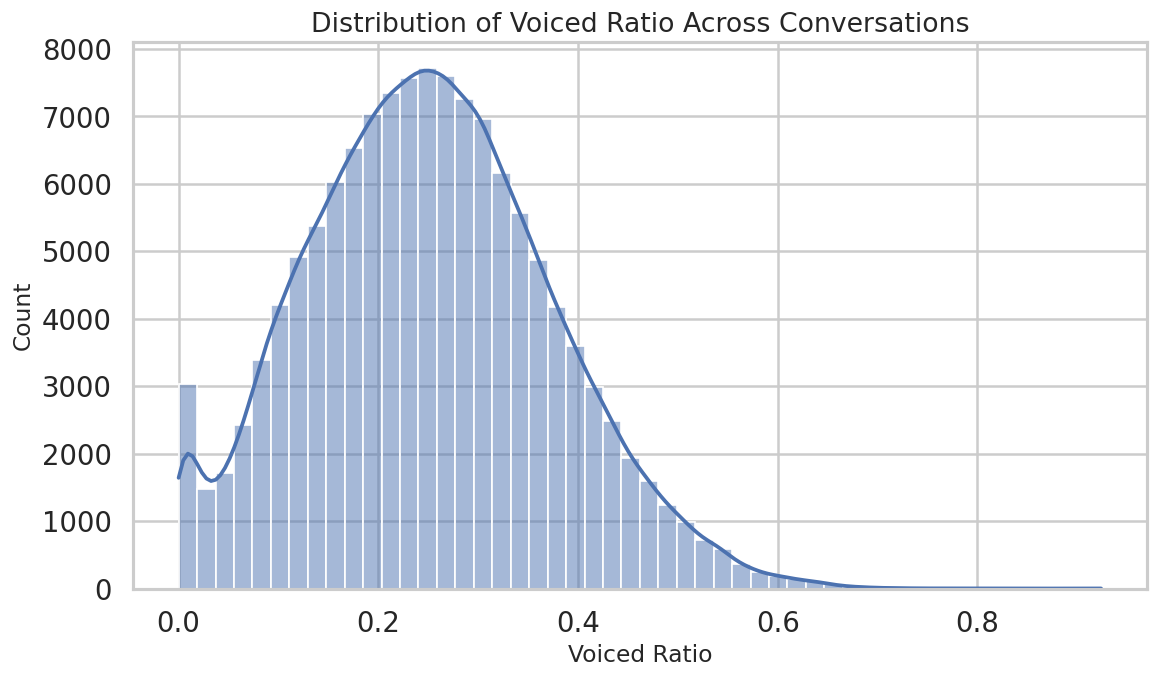

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df["voiced_ratio"], bins=50, kde=True)
plt.xlabel("Voiced Ratio")
plt.ylabel("Count")
plt.title("Distribution of Voiced Ratio Across Conversations")
plt.tight_layout()
plt.show()

## 1.3 Stability Across Robust Metrics

We assess whether different robust definitions (10–90 vs 25–75)
produce qualitatively similar results.

In [5]:
metrics = [
    ("f0_mean_p10_p90", "f0_mean_p25_p75"),
    ("f0_std_p10_p90", "f0_std_p25_p75"),
    ("f0_range_p10_p90", "f0_range_p25_p75"),
]

for m1, m2 in metrics:
    r, _ = pearsonr(df[m1].dropna(), df[m2].dropna())
    print(f"{m1} vs {m2}: r = {r:.3f}")

f0_mean_p10_p90 vs f0_mean_p25_p75: r = 0.998
f0_std_p10_p90 vs f0_std_p25_p75: r = 0.927
f0_range_p10_p90 vs f0_range_p25_p75: r = 0.874


Robust metrics are highly correlated across percentile definitions,
indicating that results are not sensitive to arbitrary trimming thresholds.

We therefore report all three versions for transparency,
while prioritizing 10–90 percentile metrics in primary analyses.

## Summary: Methodological Validation

This notebook demonstrates that:

- Raw F0 statistics are unreliable for conversational speech
- Percentile-based trimming dramatically stabilizes pitch metrics
- Voiced ratio does not compromise robust estimates
- Robust metrics are consistent across trimming strategies

These findings justify the methodological choices used throughout the study
and enable reliable large-scale analysis of prosody in social interaction.